In [1]:
%load_ext autoreload
%autoreload 2


import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib import cm
import os, sys

root_dir = os.path.abspath('../..')

if root_dir not in sys.path:
    sys.path.append(root_dir)

from src.data_loader.utils import img_polar2cart



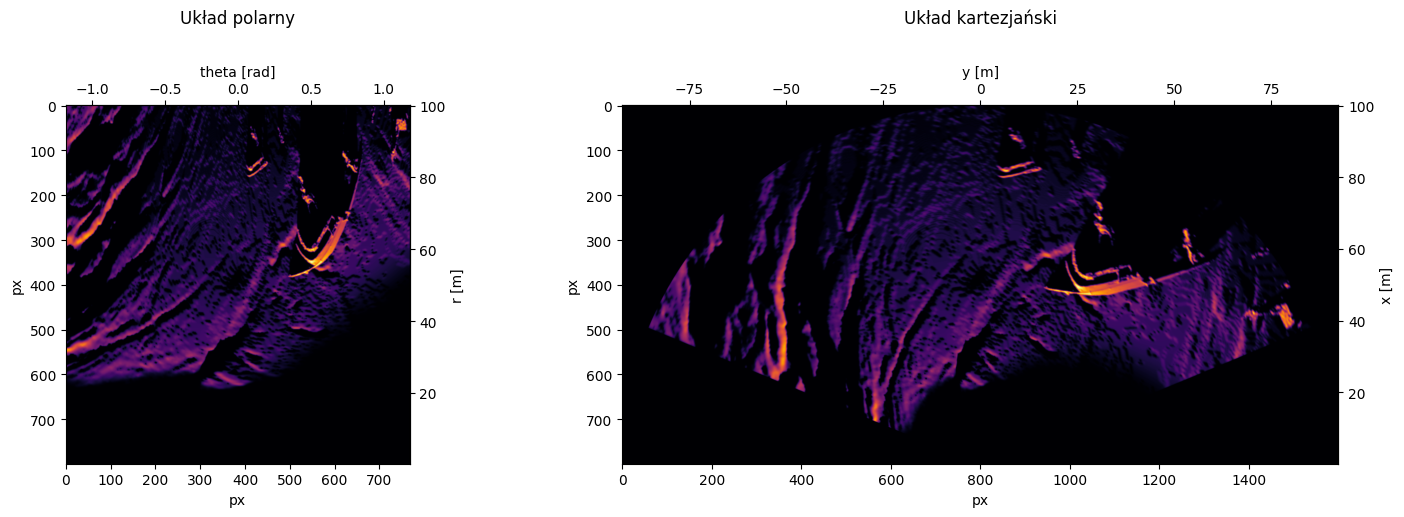

In [ ]:
# read example image
example_img_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/SonarOdometryDataset/test_scenarios/seq_3/fls/15.png'
img_org_polar = cv2.imread(example_img_pth) 

# convert to carthesian
r_min = 0.2
r_max = 100.0
fov = 135 * np.pi / 180

img_org_cart = img_polar2cart(img_org_polar, 
                              r_min, # r_min [m]
                              r_max, # r_max [m]
                              fov, # horizontal fov [rad]
                              out_shape = None, 
                              bg = 0 # fill background with desire value
                              ) 

# present example image

# additional functions def 
H_pol, W_pol = img_org_polar.shape[:2]
H_cart, W_cart = img_org_cart.shape[:2]

def pol_y_pix2m(p): return r_max - (p / H_pol) * (r_max - r_min)
def pol_y_m2pix(m): return (r_max - m) / (r_max - r_min) * H_pol

def pol_x_pix2rad(p): return -fov/2 + (p / W_pol) * fov
def pol_x_rad2pix(r): return (r + fov/2) / fov * W_pol

cart_max_y = r_max * np.sin(fov/2)

def cart_y_pix2m(p): return r_max - (p / H_cart) * r_max  # Oś X w metrach (odległość w przód, p=0 to r_max)
def cart_y_m2pix(m): return (r_max - m) / r_max * H_cart

def cart_x_pix2m(p): return -cart_max_y + (p / W_cart) * (2 * cart_max_y) # Oś Y w metrach (szerokość boczna)
def cart_x_m2pix(m): return (m + cart_max_y) / (2 * cart_max_y) * W_cart


# --- Wyświetlanie ---
row_num = 1
col_num = 2
fig, ax = plt.subplots(
    row_num, col_num, 
    figsize=(15, 5 * row_num),
    gridspec_kw={'width_ratios': [W_pol, W_cart]}
)

# === WYKRES 0: Układ polarny ===
ax[0].imshow(img_org_polar[:, :, 0], cmap = 'inferno') #, vmin=img_org_polar[:, :, 0].min(), vmax=img_org_polar[:, :, 0].max())
ax[0].set_title('Układ polarny', pad=30) 

ax[0].set_xlabel('px')
ax[0].set_ylabel('px')

sec_x_pol = ax[0].secondary_xaxis('top', functions=(pol_x_pix2rad, pol_x_rad2pix))
sec_x_pol.set_xlabel('theta [rad]')

sec_y_pol = ax[0].secondary_yaxis('right', functions=(pol_y_pix2m, pol_y_m2pix))
sec_y_pol.set_ylabel('r [m]')


# === WYKRES 1: Układ kartezjański ===
ax[1].imshow(img_org_cart[:, :, 0], cmap = 'inferno')
ax[1].set_title('Układ kartezjański', pad=30)

ax[1].set_xlabel('px')
ax[1].set_ylabel('px')

sec_x_cart = ax[1].secondary_xaxis('top', functions=(cart_x_pix2m, cart_x_m2pix))
sec_x_cart.set_xlabel('y [m]')

sec_y_cart = ax[1].secondary_yaxis('right', functions=(cart_y_pix2m, cart_y_m2pix))
sec_y_cart.set_ylabel('x [m]')

plt.tight_layout()
plt.show()

In [ ]:
# i = cv2.imread('C:/Users/janis/Projekty/Magisterka/SonarOdometry/SonarOdometryDataset/bathymetry_maps/seabed_moon.png', 0)
# print(i.shape)

(2880, 5760)


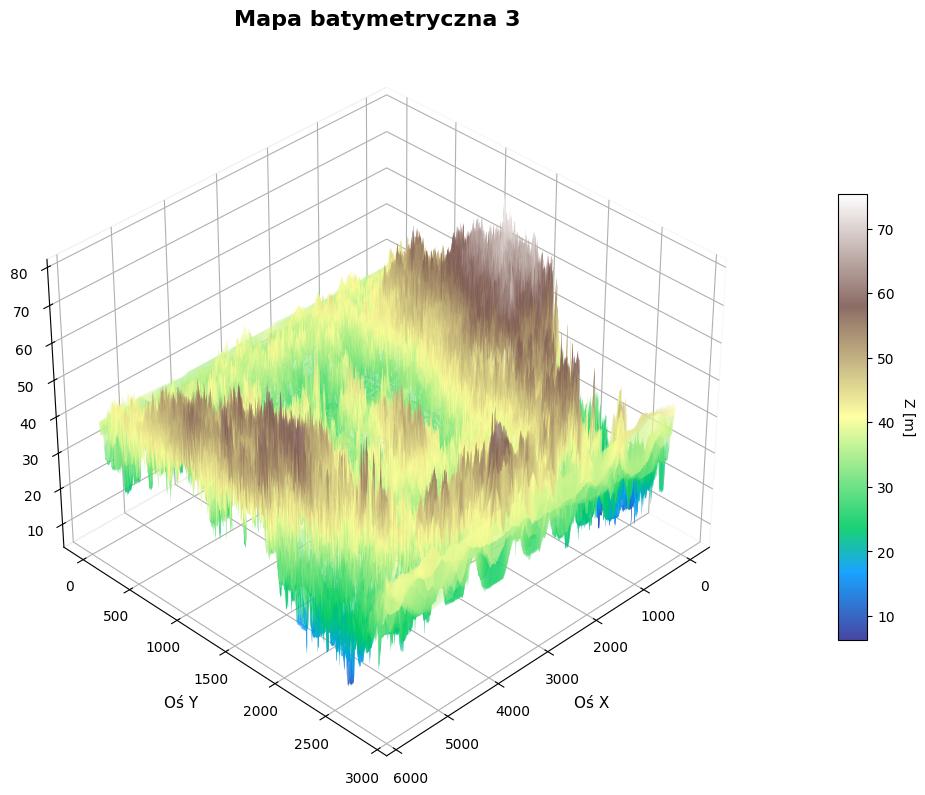

In [ ]:
# # Display preapared scenarios for simulating data 

# # seabed_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/SonarOdometryDataset/bathymetry_maps/ocean2.png'
              
# # seabed_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/SonarOdometryDataset/bathymetry_maps/fiords.png'
              
# seabed_pth = 'C:/Users/janis/Projekty/Magisterka/SonarOdometry/SonarOdometryDataset/bathymetry_maps/seabed_moon.png'
              
# title = 'Mapa batymetryczna 3'

# # 1. Wczytanie obrazu w odcieniach szarości
# Z = cv2.imread(seabed_pth, 0)
# if Z is None:
#     raise FileNotFoundError(f"Nie udało się wczytać pliku: {seabed_pth}")

# h, w = Z.shape 

# # 2. Przygotowanie siatki współrzędnych
# x = np.linspace(0, w, w)
# y = np.linspace(0, h, h)
# X, Y = np.meshgrid(x, y)
# Zf = Z.astype(np.float64)
# Zf[Zf < 10] = np.nan

# # 3. Tworzenie pojedynczego wykresu
# fig = plt.figure(figsize=(10, 8))
# ax = fig.add_subplot(1, 1, 1, projection='3d')

# surf = ax.plot_surface(
#     X, Y, Zf*0.5, 
#     cmap='terrain', 
#     linewidth=0,        # Brak czarnej siatki
#     antialiased=True,   # Wygładzanie krawędzi
#     rstride=10,          # Gęstość próbkowania wierszy (zwiększ np. do 4 dla płynniejszego obracania)
#     cstride=10,          # Gęstość próbkowania kolumn
#     alpha=0.9
# )

# # 4. Stylizacja osi i tytułu
# ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
# ax.set_xlabel('Oś X', fontsize=11, labelpad=10)
# ax.set_ylabel('Oś Y', fontsize=11, labelpad=10)
# ax.set_zlabel('Wysokość Z', fontsize=11, labelpad=10)

# # Ustawienie kąta obserwacji
# ax.view_init(elev=35, azim=45)

# # Ukrycie szarych ścian w tle
# ax.xaxis.pane.fill = False
# ax.yaxis.pane.fill = False
# ax.zaxis.pane.fill = False

# # 5. Pasek skali (colorbar)
# cbar = fig.colorbar(surf, ax=ax, shrink=0.6, aspect=15, pad=0.1)
# cbar.set_label('Z [m]', rotation=270, labelpad=15)

# plt.tight_layout()
# plt.show()
